In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("house_price_regression_dataset.csv")

In [ ]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns=df.columns.str.lower()

In [ ]:
df.columns

Index(['square_footage', 'num_bedrooms', 'num_bathrooms', 'year_built',
       'lot_size', 'garage_size', 'neighborhood_quality', 'house_price'],
      dtype='object')

In [ ]:
x=df["house_price"].value_counts()
x


house_price
2.623829e+05    1
2.501235e+05    1
1.021135e+06    1
8.343286e+05    1
1.040389e+06    1
               ..
3.584584e+05    1
2.643951e+05    1
7.495713e+05    1
2.637609e+05    1
7.425993e+05    1
Name: count, Length: 1000, dtype: int64

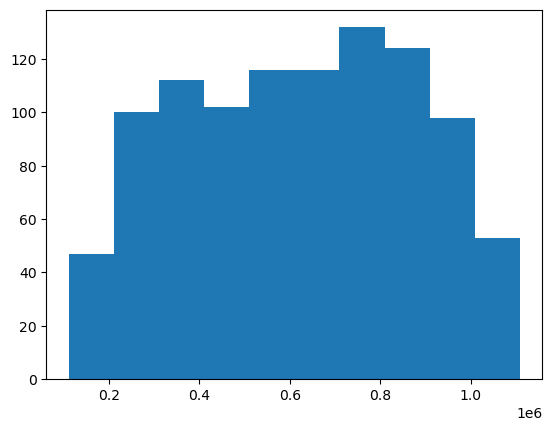

In [ ]:
a=x.index
b=x.values
plt.hist(a)
plt.show()

In [ ]:
# corelation-dependency of column with each other
# results in range 1 to -1
# 0-no relationship
# 1-3  -week
# 4-7- strong
# 7-1-   very strong


#corelation matrix

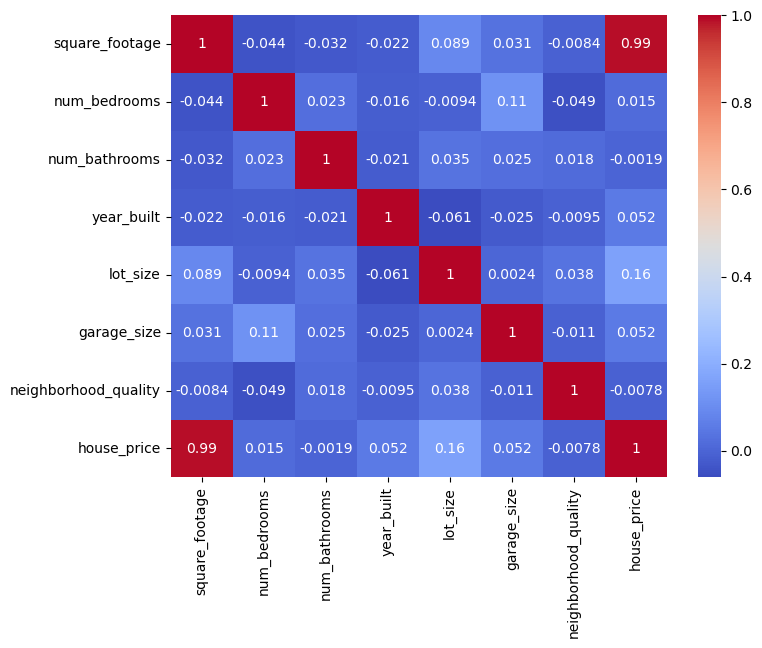

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [ ]:
df.corr()["house_price"].sort_values(ascending=False)

house_price             1.000000
square_footage          0.991261
lot_size                0.160412
garage_size             0.052133
year_built              0.051967
num_bedrooms            0.014633
num_bathrooms          -0.001862
neighborhood_quality   -0.007770
Name: house_price, dtype: float64

In [ ]:
#regression,linear,descision tree,support vector regression

In [ ]:
#label
x=df.drop(["house_price"],axis=1)
y=df["house_price"]
print(x)
print(y)

     square_footage  num_bedrooms  num_bathrooms  year_built  lot_size  \
0              1360             2              1        1981  0.599637   
1              4272             3              3        2016  4.753014   
2              3592             1              2        2016  3.634823   
3               966             1              2        1977  2.730667   
4              4926             2              1        1993  4.699073   
..              ...           ...            ...         ...       ...   
995            3261             4              1        1978  2.165110   
996            3179             1              2        1999  2.977123   
997            2606             4              2        1962  4.055067   
998            4723             5              2        1950  1.930921   
999            3268             4              2        1983  3.108790   

     garage_size  neighborhood_quality  
0              0                     5  
1              1             

In [ ]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)

print(y_test.shape)




(800, 7)
(200, 7)
(800,)
(200,)


In [ ]:
# split x and y values as train and test using train_test_split()


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
# scaling is not important for decision tree and random forest

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# split x and y values as train and test using train_test_split()
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
# scaling is not important for decision tree and random forest

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred_lr=lr.predict(x_test)
y_pred_lr

array([ 868687.10747904,  490337.89825447,  945667.12422538,
       1033402.87599249,  776698.77390588,  732444.09335309,
        995051.99156274,  885174.76924364,  796730.53817138,
        931741.09209273,  759486.73376772,  645409.40410205,
        217706.20688727, 1047436.52669429,  536985.283711  ,
        187868.55343103,  456819.02346556,  357933.98497767,
        743138.35721931,  362670.94796791,  775101.05248528,
        478174.42921702,  680966.0634508 ,  889457.56001473,
        447158.93387225,  396997.78641331,  454334.22026962,
        442837.53540886,  187336.81096628,  491668.18070411,
        279715.81740977,  895941.00057431,  783583.19778843,
        352212.91737967,  479313.28465599,  766612.6601435 ,
        474636.25109508,  572446.37288032,  303449.70619641,
        154599.27036071,  304341.05092123,  299677.00775283,
        508575.91105887,  309977.51725284, 1082131.76994764,
       1011343.63575233,  760359.56460959,  807425.57445877,
       1025548.17009415,

In [ ]:
print("R^2 score of lr on training set:",lr.score(x_train,y_train))
print("R^2 score of lr on test set:",lr.score(x_test,y_test))


R^2 score of lr on training set: 0.9985375946918145
R^2 score of lr on test set: 0.9984263636823413


In [ ]:
#checking for error-checking wrong prediction

from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--linear regression model evaluation--")
print("mean absolute error(mae):",mae(y_test,y_pred_lr))
print("mean absolute error(mae):",mse(y_test,y_pred_lr))
print("root mean squared error(rmse):",np.sqrt(mse(y_test,y_pred_lr)))




--linear regression model evaluation--
mean absolute error(mae): 8174.583600006585
mean absolute error(mae): 101434798.50563538
root mean squared error(rmse): 10071.48442413706


In [ ]:







#decision tree




# alogorithm 2:decision tree

from sklearn.tree import DecisionTreeRegressor
# model building

dtr=DecisionTreeRegressor()

# model trainining 
dtr.fit(x_train,y_train)

#model testing --x_test_data
y_pred_dt=dtr.predict(x_test)
print(y_pred_dt)






[ 821146.23390556  501720.67572174  923773.12935606 1041740.8589249
  806645.0448681   720883.65717106  955158.90638745  899849.51882009
  816939.58743084  923122.11417869  740286.55974695  666733.47346169
  234762.82447901 1041740.8589249   527544.91053417  215993.8951157
  506990.32475704  405144.67006802  742599.25333236  369407.96419172
  804433.80932186  501913.64710804  671803.94390133  891638.50869646
  432387.04102579  370260.60316679  510876.99909322  357130.1202818
  198204.12830507  440726.28481629  238220.48454485  934942.05713292
  738935.81944604  341253.22077951  454484.4215051   772740.07072754
  473629.22154242  628610.96505816  255907.13436004  146406.89625235
  308618.4072722   255907.13436004  497340.99811599  280149.18636125
 1108236.83629137 1010589.32913523  760436.88936237  826587.79697111
 1041122.11313313  719969.43529451  323701.24419015  769318.60382615
  785248.36198794  678385.98996322  509733.85039648  828512.10195891
  227515.30028798  296291.00100751  7

In [ ]:
#model evaluatio

print("R^2 score of lr on training set:",dtr.score(x_train,y_train))
print("R^2 score of lr on test set:",dtr.score(x_test,y_test),"\n\n\n")




#checking for error-checking wrong prediction

from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--linear regression model evaluation--")
print("mean absolute error(mae):",mae(y_test,y_pred_dt))
print("mean absolute error(mae):",mse(y_test,y_pred_dt))
print("root mean squared error(rmse):",np.sqrt(mse(y_test,y_pred_dt)))




R^2 score of lr on training set: 1.0
R^2 score of lr on test set: 0.9828024502515833 



--linear regression model evaluation--
mean absolute error(mae): 25979.854433026077
mean absolute error(mae): 1108534401.4662364
root mean squared error(rmse): 33294.66025455488


In [ ]:







#random forest regression






from sklearn.ensemble import RandomForestRegressor
# model building

rfr=RandomForestRegressor()

# model trainining 
rfr.fit(x_train,y_train)

#model testing --x_test_data
y_pred_rf=rfr.predict(x_test)
print(y_pred_rf)






[ 851683.98556682  507337.81383345  950467.06010144 1038635.73072234
  799148.6158705   735431.99694909  975119.58671795  883769.43984102
  817780.80932703  921495.40110441  753063.0077217   653223.23550518
  231872.82069598 1041235.03264418  550183.12252015  217883.35203988
  472011.15424113  378311.92422919  735195.70323528  359153.62952768
  773256.92742033  489603.61302504  697241.05226705  882190.66304981
  431699.28917272  371750.952505    458826.35984735  442833.81857484
  216222.68536793  459805.8576927   256674.91408213  901203.30970184
  750211.04156637  351226.33888097  487760.42851617  765719.53768365
  463611.60062732  588057.27020905  271344.69088095  155601.07577818
  310512.35025953  274264.68419947  504283.90855998  314661.00078919
 1086305.52996869  979118.49337484  777405.69031078  820484.26980637
  993617.37331265  715488.22020766  272478.32636418  746651.9515552
  810899.19487146  690564.10065383  530654.86548691  807381.69033609
  188436.87124974  326240.10138801 

In [ ]:
#model evaluatio

print("R^2 score of lr on training set:",rfr.score(x_train,y_train))
print("R^2 score of lr on test set:",rfr.score(x_test,y_test),"\n\n\n")




#checking for error-checking wrong prediction

from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--linear regression model evaluation--")
print("mean absolute error(mae):",mae(y_test,y_pred_rf))
print("mean absolute error(mae):",mse(y_test,y_pred_rf))
print("root mean squared error(rmse):",np.sqrt(mse(y_test,y_pred_rf)))




R^2 score of lr on training set: 0.9989293567385927
R^2 score of lr on test set: 0.9938244421156939 



--linear regression model evaluation--
mean absolute error(mae): 16169.77575357979
mean absolute error(mae): 398069403.09212667
root mean squared error(rmse): 19951.676698767114


In [ ]:



#support vector regressor













from sklearn.svm import SVR
# model building

svr=SVR()

# model trainining 
svr.fit(x_train,y_train)

#model testing --x_test_data
y_pred_svr=svr.predict(x_test)
print(y_pred_svr)








[629488.73199423 629422.42020361 629481.80738945 629498.34882899
 629473.76713933 629466.28843236 629493.87390434 629477.1421197
 629479.30468873 629496.22720911 629482.07229586 629452.22433257
 629412.61640701 629488.52313322 629440.72189392 629389.24488708
 629418.30200662 629406.65807359 629469.33450808 629401.77977754
 629476.3824703  629436.82788134 629459.56639638 629479.34482584
 629419.81173469 629406.55114075 629436.4177744  629429.84183887
 629414.40733872 629431.69807547 629401.46410011 629484.21824256
 629463.19304572 629414.32508465 629436.38149129 629472.01171329
 629431.65700881 629444.14265904 629423.10943594 629401.61576804
 629394.89136595 629399.7119152  629434.85600872 629410.33771078
 629502.65469874 629485.659901   629459.05252804 629478.47120831
 629489.54411867 629456.53209218 629412.19154361 629464.01534317
 629470.69419437 629463.34862549 629440.61400643 629469.05783348
 629395.47238715 629399.68072266 629465.84661894 629394.77292064
 629507.78273504 629406.07

In [ ]:
#model evaluatio

print("R^2 score of svr on training set:",svr.score(x_train,y_train))
print("R^2 score of svr on test set:",svr.score(x_test,y_test),"\n\n\n")




#checking for error-checking wrong prediction

from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--linear regression model evaluation--")
print("mean absolute error(mae):",mae(y_test,y_pred_svr))
print("mean absolute error(mae):",mse(y_test,y_pred_svr))
print("root mean squared error(rmse):",np.sqrt(mse(y_test,y_pred_svr)))




R^2 score of svr on training set: -0.0015953583487167133
R^2 score of svr on test set: -0.0011367983532217796 



--linear regression model evaluation--
mean absolute error(mae): 219472.63701781843
mean absolute error(mae): 64532133808.799385
root mean squared error(rmse): 254031.7574808303


In [ ]:
def predict_price():
    square_footage=int(input("Enter square footage:"))
    num_bedrooms=int(input("Enter no of bedroom:"))

    num_bathrooms=int(input("Enter no of bathroom:"))

    year_build=int(input("Enter year build:"))

    lot_size=int(input("Enter lot size:"))

    garage_size=int(input("Enter garage size:"))

    neiborhood_quality=int(input("Enter neibourhood quality (1-10):"))




    input_data=[[square_footage,num_bedrooms,num_bathrooms,year_build,lot_size,garage_size,neiborhood_quality]]

    test_scaled=scaler.transform(input_data)

    predicted_price=lr.predict(test_scaled)
    print(f"predicted house price:{predicted_price[0]:,.2f}")






In [ ]:
predict_price()

: 